# Dog weight regression #

Welcome to this assignment. In this asignment you will try to predict the weight of a dog.<br>

In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/bbozon/DataScience/refs/heads/main/generated_dogs.csv'
'''
The dataset consists of 10000 dogs who died of old age. It is generated using meta data from dogs.

'''
df = pd.read_csv(url)
df.head()

,Breed,Gender,Age_time_of_death,Height,Weight,Likes,Skills
0,Border Collie,Male,13.3,20.70,40.50,likes_people_better_than_dogs,high_trainability
1,Basset Hound,Male,12.7,13.65,51.02,likes_dogs_better_than_people,no_special_skills
2,Dachshund,Female,14.0,8.59,24.58,likes_dogs_better_than_people,barks_like_hell
3,Boston Terrier,Male,12.3,16.27,20.13,likes_people_better_than_dogs,no_special_skills
4,Chihuahua,Male,15.3,7.14,5.92,likes_dogs_better_than_people,barks_like_hell


# First step #


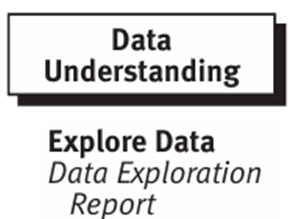


I will help you a little bit. We could try a pairplot.

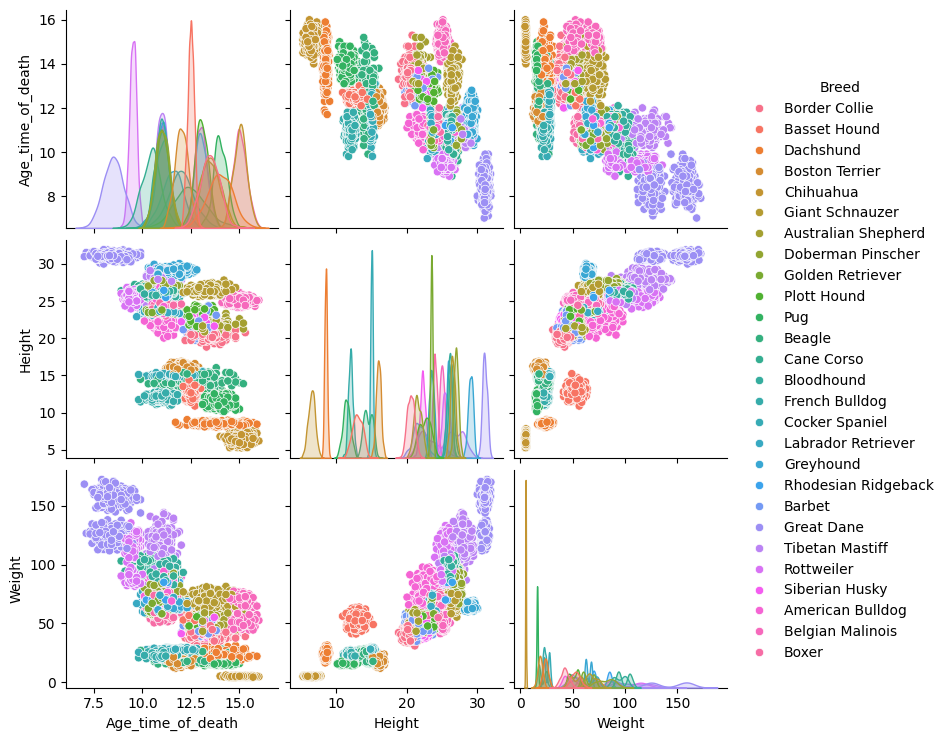

In [2]:
import seaborn as sns

sns.pairplot(df.drop(['Gender','Skills','Likes'],axis=1), hue='Breed')

1) Try different visualisations

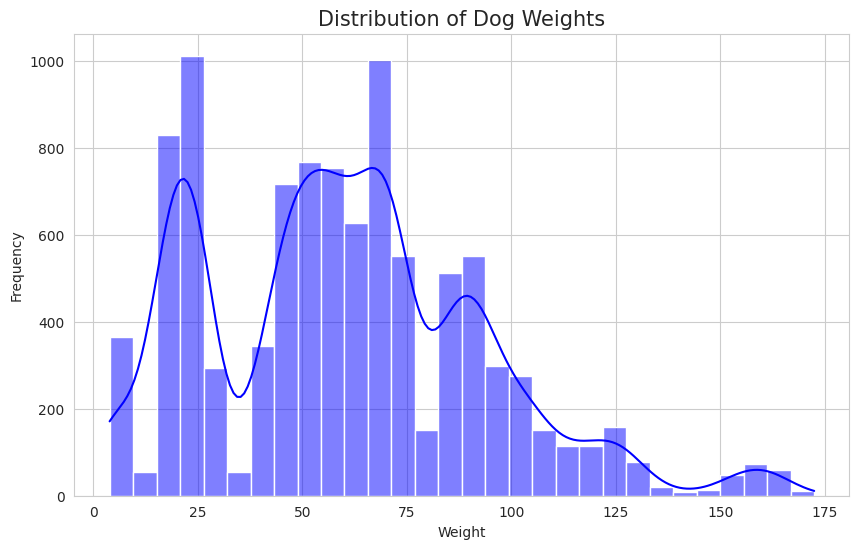

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Set global style
sns.set_style("whitegrid")

# ==========================================
# 1. Target Analysis: Distribution of Weight
# ==========================================
plt.figure(figsize=(10, 6))
sns.histplot(df['Weight'], kde=True, color='blue', bins=30)
plt.title("Distribution of Dog Weights", fontsize=15)
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()

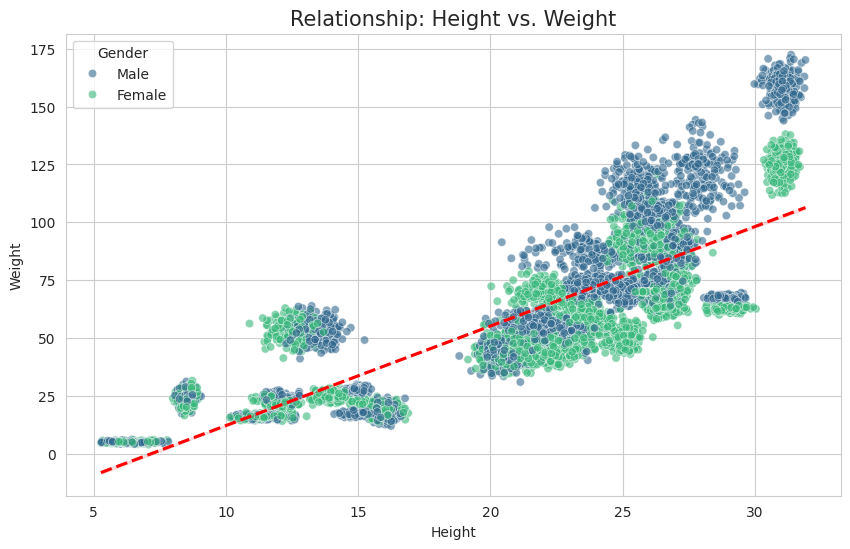

In [4]:
plt.figure(figsize=(10, 6))
# Using 'hue' to see if Gender plays a role
sns.scatterplot(data=df, x='Height', y='Weight', hue='Gender', alpha=0.6, palette='viridis')

# Add a trendline (optional, using regplot structure)
sns.regplot(data=df, x='Height', y='Weight', scatter=False, color='red', line_kws={"linestyle": "--"})

plt.title("Relationship: Height vs. Weight", fontsize=15)
plt.xlabel("Height")
plt.ylabel("Weight")
plt.show()

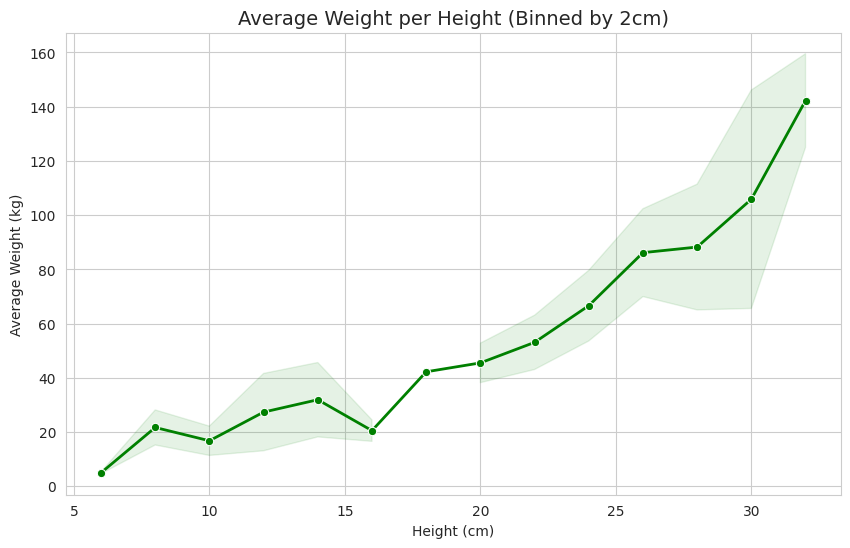

In [5]:
df_avg = df.copy()
step_size = 2 # cm
df_avg['Height_Bin'] = (round(df_avg['Height'] / step_size) * step_size).astype(int)
grouped = df_avg.groupby('Height_Bin')['Weight'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped, x='Height_Bin', y='mean', color='green', linewidth=2, marker='o')
plt.fill_between(grouped['Height_Bin'], 
                    grouped['mean'] - grouped['std'], 
                    grouped['mean'] + grouped['std'], 
                    color='green', alpha=0.1)
plt.title(f"Average Weight per Height (Binned by {step_size}cm)", fontsize=14)
plt.xlabel("Height (cm)")
plt.ylabel("Average Weight (kg)")
plt.show()

/tmp/ipykernel_64988/683615125.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Breed', y='Weight', order=order, palette="coolwarm")


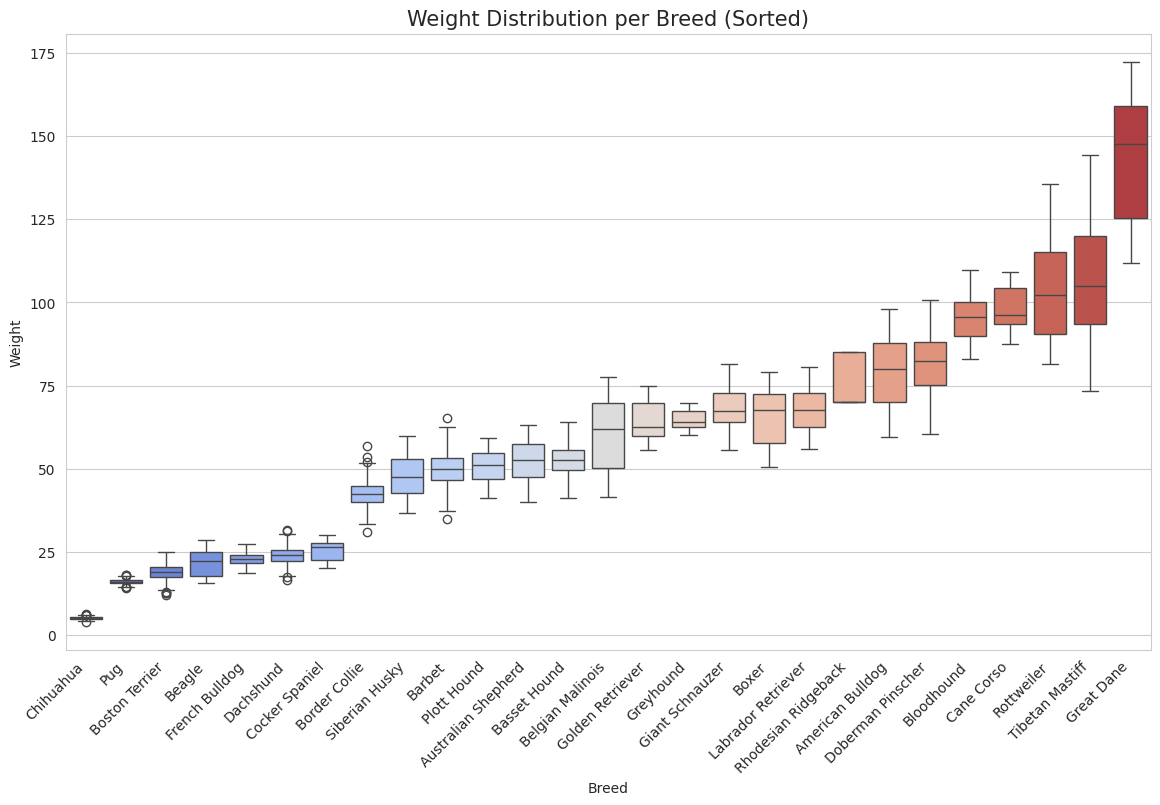

In [6]:
plt.figure(figsize=(14, 8))
# Order breeds by median weight for cleaner plot
order = df.groupby('Breed')['Weight'].median().sort_values().index

sns.boxplot(data=df, x='Breed', y='Weight', order=order, palette="coolwarm")
plt.title("Weight Distribution per Breed (Sorted)", fontsize=15)
plt.xticks(rotation=45, ha='right') # Rotate labels if there are many breeds
plt.xlabel("Breed")
plt.ylabel("Weight")
plt.show()

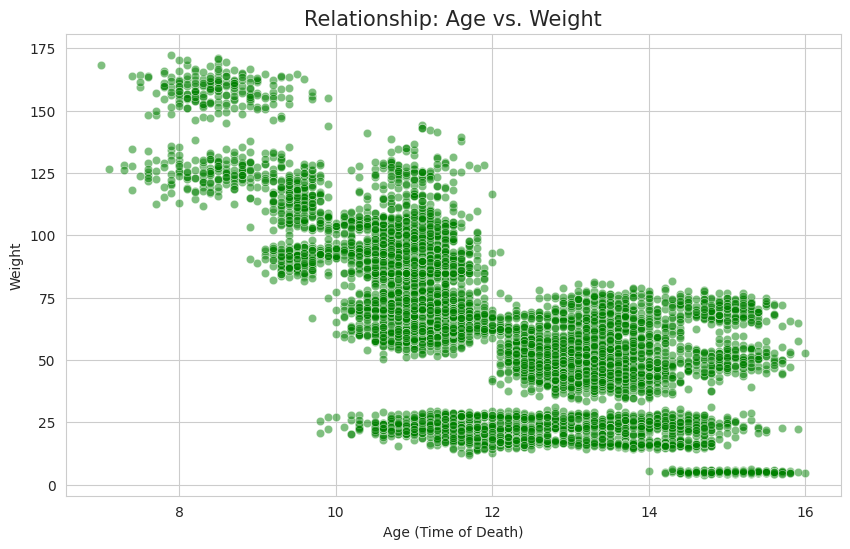

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age_time_of_death', y='Weight', alpha=0.5, color='green')
plt.title("Relationship: Age vs. Weight", fontsize=15)
plt.xlabel("Age (Time of Death)")
plt.ylabel("Weight")
plt.show()

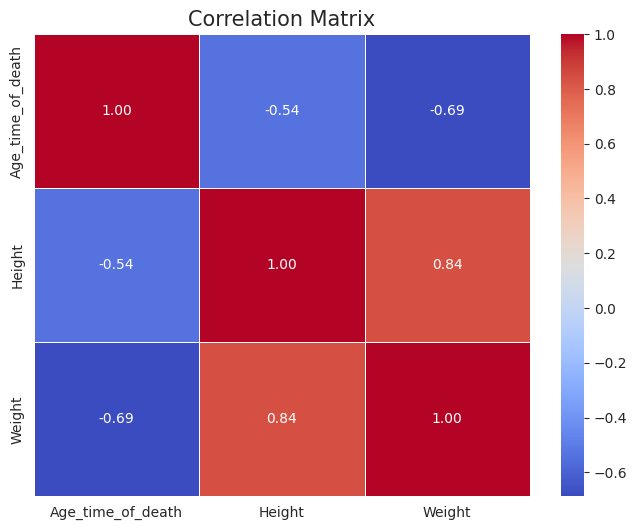

In [8]:
plt.figure(figsize=(8, 6))
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=15)
plt.show()

In [9]:
# males are heavyer then females. we can combine the breed and gender in order to ges more acurate
df['Breed_Gender'] = df['Breed'] + '_' + df['Gender']

# in average height/weigth we see a curve
df['Height2'] = df['Height']**2
df

,Breed,Gender,Age_time_of_death,Height,Weight,Likes,Skills,Breed_Gender,Height2
0,Border Collie,Male,13.3,20.70,40.50,likes_people_better_than_dogs,high_trainability,Border Collie_Male,428.4900
1,Basset Hound,Male,12.7,13.65,51.02,likes_dogs_better_than_people,no_special_skills,Basset Hound_Male,186.3225
2,Dachshund,Female,14.0,8.59,24.58,likes_dogs_better_than_people,barks_like_hell,Dachshund_Female,73.7881
3,Boston Terrier,Male,12.3,16.27,20.13,likes_people_better_than_dogs,no_special_skills,Boston Terrier_Male,264.7129
4,Chihuahua,Male,15.3,7.14,5.92,likes_dogs_better_than_people,barks_like_hell,Chihuahua_Male,50.9796
...,...,...,...,...,...,...,...,...,...
9995,Giant Schnauzer,Male,14.3,27.27,74.61,likes_dogs_better_than_people,high_trainability,Giant Schnauzer_Male,743.6529
9996,Australian Shepherd,Male,14.4,21.44,58.92,likes_people_better_than_dogs,high_trainability,Australian Shepherd_Male,459.6736
9997,Pug,Female,13.7,12.53,15.46,likes_people_better_than_dogs,no_special_skills,Pug_Female,157.0009
9998,Golden Retriever,Female,11.0,23.80,58.22,likes_everybody,high_trainability,Golden Retriever_Female,566.4400


# Second step #

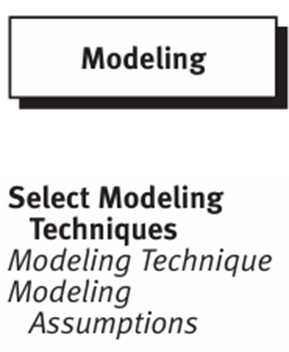

1) Select different models

# Third step #

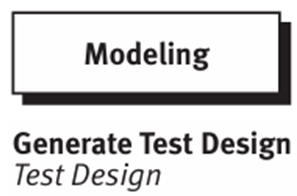

1) Drop columns or not, use _get_dummies or not, etc.<br>
2) Split your dataset in training, validation, and test.

# Fourth step #

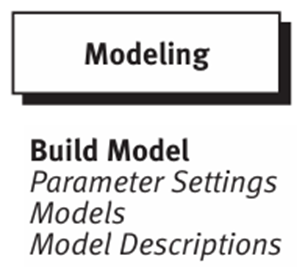

1) Apply your models.

# Fifth step #
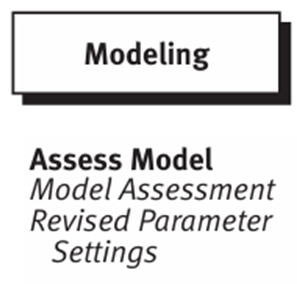

1) Assess your models.

# And repeat!!!! #
1) Go back to 1st, 2nd or 3rd step and improve your results!



In [10]:
from RegressionEvaluator import RegressionEvaluator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.exceptions import ConvergenceWarning

# 2. Setup Evaluator
reg_eval = RegressionEvaluator(name="Dog Weight Prediction")


reg_eval.add_option(scaling=False, dummies=True,cols_to_drop=['Breed_Gender',"Height2"])

reg_eval.add_option(scaling=True, dummies=True,cols_to_drop=['Breed_Gender',"Height2"])

reg_eval.add_option(scaling=True, dummies=True, cols_to_drop=['Breed'])

reg_eval.add_option(scaling=False, dummies=True,cols_to_drop=['Breed',"Height"])

reg_eval.add_option(scaling=True, dummies=True,cols_to_drop=['Breed',"Height"])


# 4. Add Models

# A. Linear Regression (Simple Baseline)
reg_eval.add_model(
    name='LinearRegression',
    model=LinearRegression(),
    params={} # No hyperparameters for standard Linear Regression
)

# B. Random Forest (Handles non-linear relationships well)
reg_eval.add_model(
    name='RandomForest',
    model=RandomForestRegressor(random_state=42, n_jobs=-1),
    params={
        'n_estimators': [100, 200,300,500,1000],
        'max_depth': [5, 10,50, None]
    }
)

# C. XGBoost (High Performance)
reg_eval.add_model(
    name='XGBoost',
    model=XGBRegressor(random_state=42, n_jobs=-1),
    params={
        'n_estimators': [100, 200,500,1000],
        'max_depth': [3, 5,7,10,20],
        'learning_rate': [0.01, 0.1,0.2]
    }
)

# 5. Run
# Target column is 'Weight'
reg_eval.run_experiments(df, target_col='Weight', refit='r2')







🚀 START REGRESSION EXPERIMENT: DOG WEIGHT PREDICTION
📊 Target Column: 'Weight'
📊 Time Series Mode: False
📊 Optimizing for: r2

--- ⚙️ Processing Opt0_S0_D1 ---
   ✅ LinearRegression: r2=0.9687
   ✅ RandomForest: r2=0.9871
   ✅ XGBoost: r2=0.9875

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ LinearRegression: r2=0.9687


Process LokyProcess-42:
Process LokyProcess-43:
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/robin/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py", line 528, in _process_worker
    with worker_exit_lock:
  File "/home/robin/.venv/lib/python3.10/site-packages/joblib/externals/loky/backend/synchronize.py", line 119, in __enter__
    return self._semlock.acquire()
KeyboardInterrupt
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/robin/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py", line 528, in _proc

KeyboardInterrupt: 


=== [Dog Weight Prediction] Top 15 Results (Sorted by r2) ===
           Model Option_ID                   Config  root_mean_squared_error       r2  mean_absolute_error  max_depth  n_estimators  learning_rate
LinearRegression      Opt3  Opt3 (Scale:No Dum:Yes)                 3.544331 0.988706             2.346191        NaN           NaN            NaN
LinearRegression      Opt4 Opt4 (Scale:Yes Dum:Yes)                 3.544331 0.988706             2.346191        NaN           NaN            NaN
LinearRegression      Opt2 Opt2 (Scale:Yes Dum:Yes)                 3.545145 0.988701             2.347604        NaN           NaN            NaN
         XGBoost      Opt1 Opt1 (Scale:Yes Dum:Yes)                 3.727418 0.987507             2.483297        5.0        1000.0           0.01
         XGBoost      Opt0  Opt0 (Scale:No Dum:Yes)                 3.727418 0.987507             2.483297        5.0        1000.0           0.01
         XGBoost      Opt1 Opt1 (Scale:Yes Dum:Yes)    

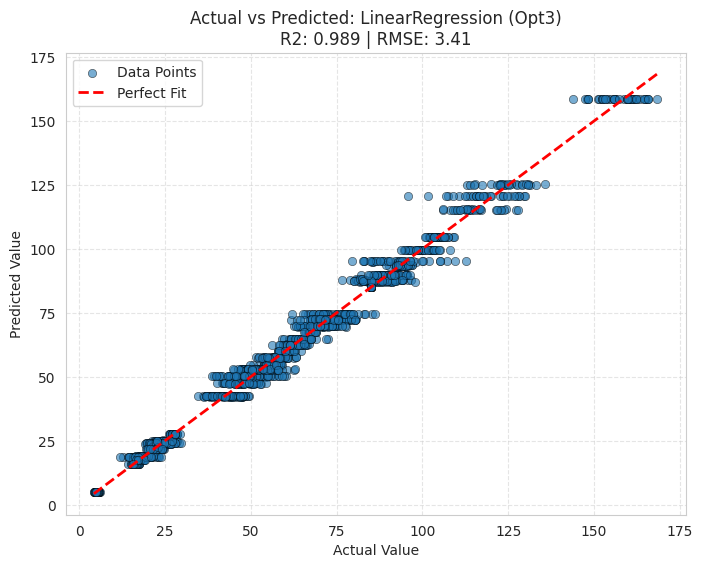


--- Analyzing Random Forest Parameters ---
ℹ️ Auto-selected model: 'LinearRegression' (Best r2)
No varying parameters to plot.


In [ ]:
# 6. Results
# Print table sorted by R2 (Higher is better)
reg_eval.print_results(sort_by='r2', top_n=15)

# 7. Visualizations
print("\n--- Visualizing Best Model Performance ---")
# Scatter plot: X=Echt gewicht, Y=Voorspeld gewicht. (Liefst op de diagonaal)
reg_eval.plot_actual_vs_predicted(best_metric='r2')

print("\n--- Analyzing Random Forest Parameters ---")
reg_eval.plot_parameter_impact(target_model=None, metric='r2')